In [47]:
from pathlib import Path
import sys

# Make sibling package imports work regardless of notebook launch directory.
project_root = Path.cwd()
if not (project_root / "ML_pipeline").exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from ML_pipeline.data_preprocessing import HeartbeatDataProcessor


In [48]:
folder_path='../data/PAMAP2_Dataset/Protocol/'
filtered_df_path='../ML_pipeline/'
processed_data = HeartbeatDataProcessor(
    folder_path,
    filtered_df_path,
    include_amplitude=False,
    include_frequency=True,
)
processed_data.preprocess_subjects(range(101,109))
# print(processed_data.df_filtered.head(3))
# print(processed_data.filtered_index.head(3))


Selected DataFrame columns have 0.2913% NaNs.
Interpolating selected columns...
Selected DataFrame columns now have 0.019% NaNs!

successfully loaded subject 101
Selected DataFrame columns have 0.4147% NaNs.
Interpolating selected columns...
Selected DataFrame columns now have 0.0327% NaNs!

successfully loaded subject 102
Selected DataFrame columns have 0.1624% NaNs.
Interpolating selected columns...
Selected DataFrame columns now have 0.0117% NaNs!

successfully loaded subject 103
Selected DataFrame columns have 0.3568% NaNs.
Interpolating selected columns...
Selected DataFrame columns now have 0.0095% NaNs!

successfully loaded subject 104
Selected DataFrame columns have 0.3409% NaNs.
Interpolating selected columns...
Selected DataFrame columns now have 0.0268% NaNs!

successfully loaded subject 105
Selected DataFrame columns have 0.2521% NaNs.
Interpolating selected columns...
Selected DataFrame columns now have 0.0349% NaNs!

successfully loaded subject 106
Selected DataFrame colu

In [49]:
print(processed_data.df_filtered.head(3))


   timestamp  activity_id  hand_temp  hand_acc16_x  hand_acc16_y  \
0      72.00            1    33.8125     -9.688065     -1.650258   
1      72.01            1    33.8125     -9.687810     -1.657005   
2      72.02            1    33.8125     -9.677891     -1.668481   

   hand_acc16_z  hand_gyro_x  hand_gyro_y  hand_gyro_z  hand_mag_x  ...  \
0      0.581883    -0.026334     0.004443    -0.019833   47.736937  ...   
1      0.552760    -0.014383     0.008403    -0.015169   47.688856  ...   
2      0.544738    -0.006325     0.014332    -0.009980   47.633992  ...   

   ankle_acc16_y  ankle_acc16_z  ankle_gyro_x  ankle_gyro_y  ankle_gyro_z  \
0       0.075480      -2.817121      0.021134     -0.022933      0.008414   
1       0.090951      -2.802223      0.026437     -0.019528      0.004282   
2       0.101458      -2.785111      0.026889     -0.012864      0.000207   

   ankle_mag_x  ankle_mag_y  ankle_mag_z  subject_id  interval_id  
0   -36.278799    37.605045   -17.471064         

## Random Forest on subject segments

This notebook uses only time-domain and FFT-domain features (no amplitude-domain features).


In [50]:
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline

slices = []
for i in range(101, 109):
    slices.extend([s for s in processed_data.subject_segment_dict[i] if not s.empty])

feature_rows = []
labels = []
groups = []

for slice_df in slices:
    if slice_df.empty:
        continue

    label = int(slice_df["activity_id"].mode().iloc[0])
    row = processed_data.extract_random_forest_features(slice_df).to_dict()

    feature_rows.append(row)
    labels.append(label)
    groups.append(int(slice_df["interval_id"].iloc[0]))

X = pd.DataFrame(feature_rows)
y = pd.Series(labels, name="activity_id")




groups = pd.Series(groups, name="interval_id")


In [51]:
display(X.head(3))
display(y.head(3))
display(groups.head(3))
# Combine activity labels into broader classes.
# 2 -> 1 (resting), 7 -> 4 (walking), 17 -> 16 (house work)
y = y.replace({2: 1, 7: 4, 17: 16})

,hand_acc16_x_mean,hand_acc16_y_mean,hand_acc16_z_mean,hand_gyro_x_mean,hand_gyro_y_mean,hand_gyro_z_mean,hand_mag_x_mean,hand_mag_y_mean,hand_mag_z_mean,chest_acc16_x_mean,...,chest_mag_corr_yz,ankle_acc16_corr_xy,ankle_acc16_corr_xz,ankle_acc16_corr_yz,ankle_gyro_corr_xy,ankle_gyro_corr_xz,ankle_gyro_corr_yz,ankle_mag_corr_xy,ankle_mag_corr_xz,ankle_mag_corr_yz
0,-1.522230,7.894671,5.366094,-0.019691,0.052850,-0.081588,-6.931476,-66.501091,-6.595853,-1.915401,...,0.922201,0.115668,0.045069,0.669181,0.031072,-0.330770,0.044812,-0.933076,-0.732066,0.673002
1,-2.586198,8.129602,4.811292,0.068599,0.040060,-0.095426,1.392746,-68.249521,-0.996447,-1.779854,...,0.811479,-0.065473,-0.008314,0.426253,-0.098054,-0.540396,-0.108184,-0.588680,-0.264869,0.113711
2,-1.379686,8.631725,3.023261,0.321204,-0.650477,0.065961,4.570088,-66.982728,9.983487,-1.077086,...,0.971797,0.312765,-0.282352,-0.415061,0.528623,-0.477815,-0.184119,-0.868160,0.469792,-0.833318


0    1
1    1
2    1
Name: activity_id, dtype: int64

0    0
1    0
2    0
Name: interval_id, dtype: int64

In [52]:
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt

print("Class counts (combined labels):")
print(y.value_counts().sort_index())

labels_sorted = np.sort(y.unique())
gkf = GroupKFold(n_splits=5)

fold_rows = []
all_true = []
all_pred = []

for fold_idx, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=groups), start=1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    rf_pipeline = Pipeline([
        (
            "rf",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42,
                max_depth=24,
                n_jobs=-1,
                criterion="gini",
                class_weight="balanced_subsample",
            ),
        ),
    ])

    rf_pipeline.fit(X_train, y_train)
    y_pred = rf_pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        average="macro",
        zero_division=0,
    )

    fold_rows.append(
        {
            "fold": fold_idx,
            "accuracy": acc,
            "macro_precision": prec_macro,
            "macro_recall": rec_macro,
            "macro_f1": f1_macro,
            "n_test": len(test_idx),
        }
    )

    all_true.append(y_test.to_numpy())
    all_pred.append(y_pred)

    print(
        f"Fold {fold_idx}: "
        f"acc={acc:.4f}, macro_f1={f1_macro:.4f}, n_test={len(test_idx)}"
    )

cv_metrics = pd.DataFrame(fold_rows)
print("\n5-fold metrics:")
print(cv_metrics)

print("\nAverage performance (5-fold):")
print(
    cv_metrics[["accuracy", "macro_precision", "macro_recall", "macro_f1"]]
    .mean()
    .to_frame("mean")
    .join(
        cv_metrics[["accuracy", "macro_precision", "macro_recall", "macro_f1"]]
        .std(ddof=1)
        .to_frame("std")
    )
)

y_true_all = np.concatenate(all_true)
y_pred_all = np.concatenate(all_pred)

print("\nClassification report (all fold predictions combined):")
print(classification_report(y_true_all, y_pred_all, labels=labels_sorted, zero_division=0))


Class counts (combined labels):
activity_id
1     3586
3     1802
4     4094
5      910
6     1562
12     980
13     843
16    3948
24     378
Name: count, dtype: int64
Fold 1: acc=0.9130, macro_f1=0.8462, n_test=3621
Fold 2: acc=0.9602, macro_f1=0.8476, n_test=3619
Fold 3: acc=0.8563, macro_f1=0.9172, n_test=3619
Fold 4: acc=0.9591, macro_f1=0.9505, n_test=3618
Fold 5: acc=0.9432, macro_f1=0.7174, n_test=3626

5-fold metrics:
   fold  accuracy  macro_precision  macro_recall  macro_f1  n_test
0     1  0.913007         0.878086      0.822425  0.846199    3621
1     2  0.960210         0.856480      0.841077  0.847636    3619
2     3  0.856314         0.939455      0.923665  0.917168    3619
3     4  0.959093         0.961569      0.940651  0.950519    3618
4     5  0.943188         0.728870      0.716983  0.717354    3626

Average performance (5-fold):
                     mean       std
accuracy         0.926363  0.043547
macro_precision  0.872892  0.091287
macro_recall     0.848960  0


Confusion matrix (5-fold pooled predictions):
                     Resting  Standing  Walking  Running  Cycling  \
Resting                 3268       199        0        0        1   
Standing                 411      1198        0        0        0   
Walking                    0         4     4023        0        0   
Running                    0         6       10      880        0   
Cycling                    1         0        0        0     1489   
Ascending \nStairs         0         0       16        0        0   
Descending \nStairs        1         3       18        0        0   
House Work                 4        62       10        0        6   
Rope \nJumping             0         2        3        5        1   

                     Ascending \nStairs  Descending \nStairs  House Work  \
Resting                               0                    0         118   
Standing                              0                    0         193   
Walking                           

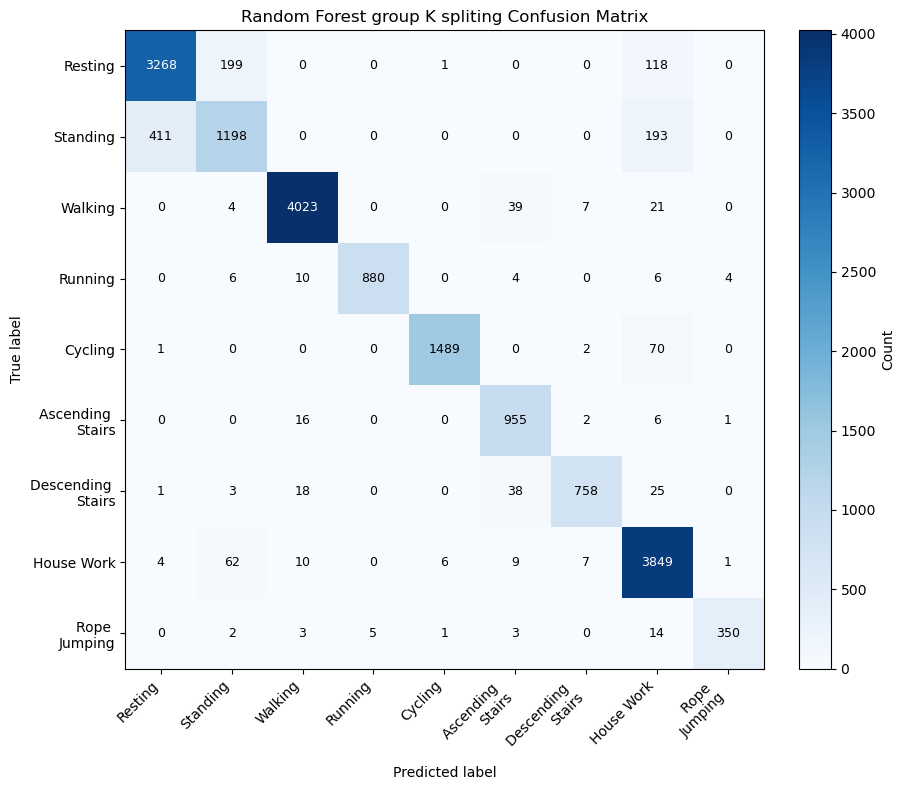

In [56]:
# Activity labels after class-combination:
# 2 -> 1 (Resting), 7 -> 4 (Walking), 17 -> 16 (House Work)

# Use combined-category names in confusion matrix axes.
activity_name_map = {
    1: "Resting",
    3: "Standing",
    4: "Walking",
    5: "Running",
    6: "Cycling",
    9: "Watching TV",
    10: "Computer Work",
    11: "Car Driving",
    12: "Ascending \nStairs",
    13: "Descending \nStairs",
    16: "House Work",
    18: "Folding Laundry",
    19: "House Cleaning",
    20: "Playing Soccer",
    24: "Rope \nJumping",
}

def _label_with_prefix(activity_id, prefix):
    name = activity_name_map.get(int(activity_id), f"ID{int(activity_id)}")
    return f"{name}"

cm = pd.DataFrame(
    confusion_matrix(y_true_all, y_pred_all, labels=labels_sorted),
    index=[_label_with_prefix(lbl, "T") for lbl in labels_sorted],
    columns=[_label_with_prefix(lbl, "P") for lbl in labels_sorted],
)

print("\nConfusion matrix (5-fold pooled predictions):")
print(cm)




# Pretty, colorized confusion matrix saved as PNG.
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm.values, cmap="Blues")

ax.set_xticks(np.arange(len(cm.columns)))
ax.set_yticks(np.arange(len(cm.index)))
ax.set_xticklabels(cm.columns, rotation=45, ha="right")
ax.set_yticklabels(cm.index)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Random Forest group K spliting Confusion Matrix")

# Annotate each cell with count value.
threshold = cm.values.max() / 2 if cm.values.size else 0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        value = cm.iat[i, j]
        color = "white" if value > threshold else "black"
        ax.text(j, i, str(value), ha="center", va="center", color=color, fontsize=9)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Count")
fig.tight_layout()

output_png = "random_forest_group_K_split_confusion_matrix.png"
fig.savefig(output_png, dpi=200, bbox_inches="tight")
print(f"\nSaved confusion group K split matrix PNG: {output_png}")
plt.show()

In [54]:
import matplotlib.pyplot as plt

print("Class counts:")
print(y.value_counts().sort_index())

splitter = GroupShuffleSplit(n_splits=3, test_size=0.2, random_state=42)
print(splitter.get_n_splits(X, y, groups=groups))
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

rf_pipeline = Pipeline([
    (
        "rf",
        RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            max_depth=24,
            n_jobs=-1,
            criterion="gini",
            class_weight="balanced_subsample",
        ),
    ),
])

rf_pipeline.fit(X_train, y_train)
y_pred = rf_pipeline.predict(X_test)

print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred, zero_division=0))

labels_sorted = np.sort(np.unique(np.concatenate([y_test.to_numpy(), y_pred])))


Class counts:
activity_id
1     3586
3     1802
4     4094
5      910
6     1562
12     980
13     843
16    3948
24     378
Name: count, dtype: int64
3

Accuracy: 0.9473

Classification report:
              precision    recall  f1-score   support

           1       0.92      0.98      0.95       482
           3       0.97      0.88      0.92       648
           4       0.95      0.93      0.94       190
           5       0.95      0.98      0.97       497
           6       1.00      0.97      0.98       215
          12       0.80      1.00      0.89        47
          13       0.97      0.93      0.95       199
          16       0.93      0.99      0.96       999
          24       1.00      0.74      0.85       141

    accuracy                           0.95      3418
   macro avg       0.94      0.93      0.93      3418
weighted avg       0.95      0.95      0.95      3418




Confusion matrix (test set):
                     Resting  Standing  Walking  Running  Cycling  \
Resting                  473         0        0        0        0   
Standing                  39       570        0        0        0   
Walking                    0         1      176        0        0   
Running                    0         4        0      486        0   
Cycling                    0         0        0        0      208   
Ascending \nStairs         0         0        0        0        0   
Descending \nStairs        0         3        7        0        0   
House Work                 0         8        0        0        1   
Rope Jumping               0         2        2       23        0   

                     Ascending \nStairs  Descending \nStairs  House Work  \
Resting                               0                    0           9   
Standing                              0                    0          39   
Walking                               5            

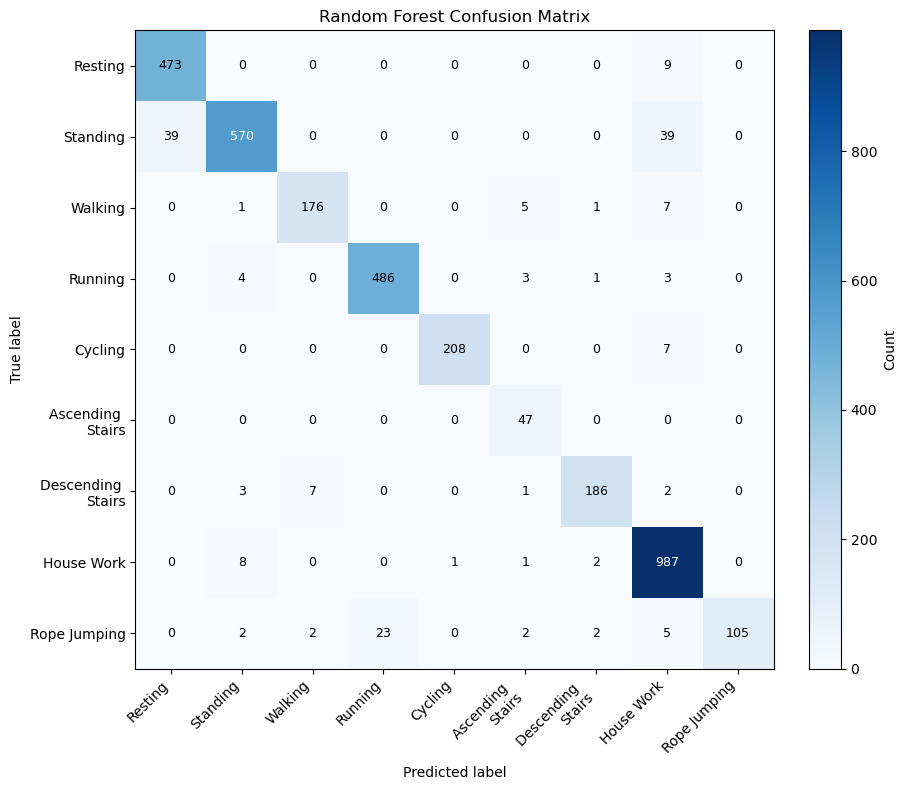

In [57]:
# Activity labels after class-combination:
# 2 -> 1 (Resting), 7 -> 4 (Walking), 17 -> 16 (House Work)

# Use combined-category names in confusion matrix axes.
activity_name_map = {
    1: "Resting",
    3: "Standing",
    4: "Walking",
    5: "Running",
    6: "Cycling",
    9: "Watching TV",
    10: "Computer Work",
    11: "Car Driving",
    12: "Ascending \nStairs",
    13: "Descending \nStairs",
    16: "House Work",
    18: "Folding Laundry",
    19: "House Cleaning",
    20: "Playing Soccer",
    24: "Rope Jumping",
}

def _label_with_prefix(activity_id, prefix):
    name = activity_name_map.get(int(activity_id), f"ID{int(activity_id)}")
    return f"{name}"

cm = pd.DataFrame(
    confusion_matrix(y_test, y_pred, labels=labels_sorted),
    index=[_label_with_prefix(lbl, "T") for lbl in labels_sorted],
    columns=[_label_with_prefix(lbl, "P") for lbl in labels_sorted],
)

print("\nConfusion matrix (test set):")
print(cm)




# Pretty, colorized confusion matrix saved as PNG.
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm.values, cmap="Blues")

ax.set_xticks(np.arange(len(cm.columns)))
ax.set_yticks(np.arange(len(cm.index)))
ax.set_xticklabels(cm.columns, rotation=45, ha="right")
ax.set_yticklabels(cm.index)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Random Forest Confusion Matrix")

# Annotate each cell with count value.
threshold = cm.values.max() / 2 if cm.values.size else 0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        value = cm.iat[i, j]
        color = "white" if value > threshold else "black"
        ax.text(j, i, str(value), ha="center", va="center", color=color, fontsize=9)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Count")
fig.tight_layout()

output_png = "random_forest_confusion_matrix.png"
fig.savefig(output_png, dpi=200, bbox_inches="tight")
print(f"\nSaved confusion matrix PNG: {output_png}")
plt.show()